# 04 Model Interpretation

目标：读取训练后的评估和SHAP输出，形成论文第五章所需的解释性分析。不在Notebook中重复训练模型。


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

outputs = PROJECT_ROOT / "outputs"
experiment = "iv_002_050"


In [2]:
metrics_path = outputs / "tables/all_metrics_train_valid_test.csv"
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    display(metrics[metrics["Scheme"] == experiment])
else:
    print("No metrics found. Run scripts/train.py first.")


,AUC,PR_AUC,Precision,Recall,F1,KS,Threshold,Scheme,Model,Split
9,0.856557,0.376251,0.392381,0.405283,0.398728,0.556422,0.850027,iv_002_050,woe_lr,Train
10,0.828491,0.325133,0.388433,0.342209,0.363859,0.516564,0.850027,iv_002_050,woe_lr,Valid
11,0.834084,0.302522,0.343805,0.379825,0.360918,0.511831,0.850027,iv_002_050,woe_lr,Test
12,0.877920,0.492735,0.500076,0.454327,0.476105,0.593269,0.734682,iv_002_050,random_forest,Train
13,0.856978,0.411463,0.492401,0.372781,0.424322,0.543684,0.734682,iv_002_050,random_forest,Valid
14,0.858872,0.434209,0.446416,0.408044,0.426368,0.546993,0.734682,iv_002_050,random_forest,Test
15,0.964465,0.730933,0.670229,0.672995,0.671609,0.792491,0.795012,iv_002_050,xgboost,Train
16,0.914573,0.541694,0.566474,0.483235,0.521554,0.666744,0.795012,iv_002_050,xgboost,Valid
17,0.898320,0.506422,0.507381,0.479403,0.492995,0.644110,0.795012,iv_002_050,xgboost,Test


In [3]:
topk_path = outputs / "tables/all_topk_train_valid_test_with_lift.csv"
if topk_path.exists():
    topk = pd.read_csv(topk_path)
    display(topk[(topk["Scheme"] == experiment) & (topk["Split"] == "Test")])
else:
    print("No TopK table found. Run scripts/train.py first.")


,TopRate,TopN,Precision,RecallCapture,Lift,Scheme,Model,Split
44,0.01,885,0.583051,0.167369,16.752263,iv_002_050,woe_lr,Test
45,0.03,2657,0.389161,0.335388,11.181396,iv_002_050,woe_lr,Test
46,0.05,4429,0.294423,0.422965,8.459388,iv_002_050,woe_lr,Test
47,0.10,8858,0.184240,0.529355,5.293605,iv_002_050,woe_lr,Test
56,0.01,885,0.831638,0.238729,23.894701,iv_002_050,random_forest,Test
57,0.03,2657,0.464434,0.400259,13.344142,iv_002_050,random_forest,Test
58,0.05,4429,0.329646,0.473565,9.471401,iv_002_050,random_forest,Test
59,0.10,8858,0.210544,0.604930,6.049371,iv_002_050,random_forest,Test
68,0.01,885,0.876836,0.251703,25.193326,iv_002_050,xgboost,Test
69,0.03,2657,0.532179,0.458644,15.290613,iv_002_050,xgboost,Test


In [4]:
shap_path = outputs / experiment / "shap/shap_importance.csv"
if shap_path.exists():
    shap_imp = pd.read_csv(shap_path)
    display(shap_imp.head(30))
else:
    print("No SHAP table found. Run scripts/explain.py first.")


,Feature,MeanSHAP,MeanAbsSHAP,MedianSHAP,PositiveSHAPRate,NegativeSHAPRate,SHAPShare,BaseFeature,FeatureCategory,RiskMechanism,FeatureType
0,C13,-0.272804,0.459095,-0.191199,0.3308,0.6692,0.079176,C13,行为计数统计特征,批量聚集与实体关联异常,numeric
1,C1,-0.042129,0.243508,-0.155087,0.2274,0.7726,0.041996,C1,行为计数统计特征,批量聚集与实体关联异常,numeric
2,TransactionAmt_log,-0.074965,0.241479,-0.117417,0.2976,0.7024,0.041646,TransactionAmt_log,交易基础特征,交易场景异常,numeric
3,C5,-0.094090,0.216125,0.081459,0.6246,0.3754,0.037273,C5,行为计数统计特征,批量聚集与实体关联异常,numeric
4,card6,-0.060777,0.206173,-0.162062,0.2430,0.7570,0.035557,card6,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
5,P_emaildomain,-0.024476,0.157068,0.055478,0.6436,0.3564,0.027088,P_emaildomain,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
6,card1,-0.072318,0.150474,-0.052958,0.3680,0.6320,0.025951,card1,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
7,V70,-0.057650,0.149952,0.062936,0.6578,0.3422,0.025861,V70,Vesta聚合统计特征,批量聚集与实体关联异常,numeric
8,card2,-0.058080,0.145911,-0.029058,0.4286,0.5714,0.025164,card2,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
9,M4,-0.039446,0.142084,-0.103907,0.4456,0.5544,0.024504,M4,身份匹配一致性特征,身份一致性异常,categorical_encoded


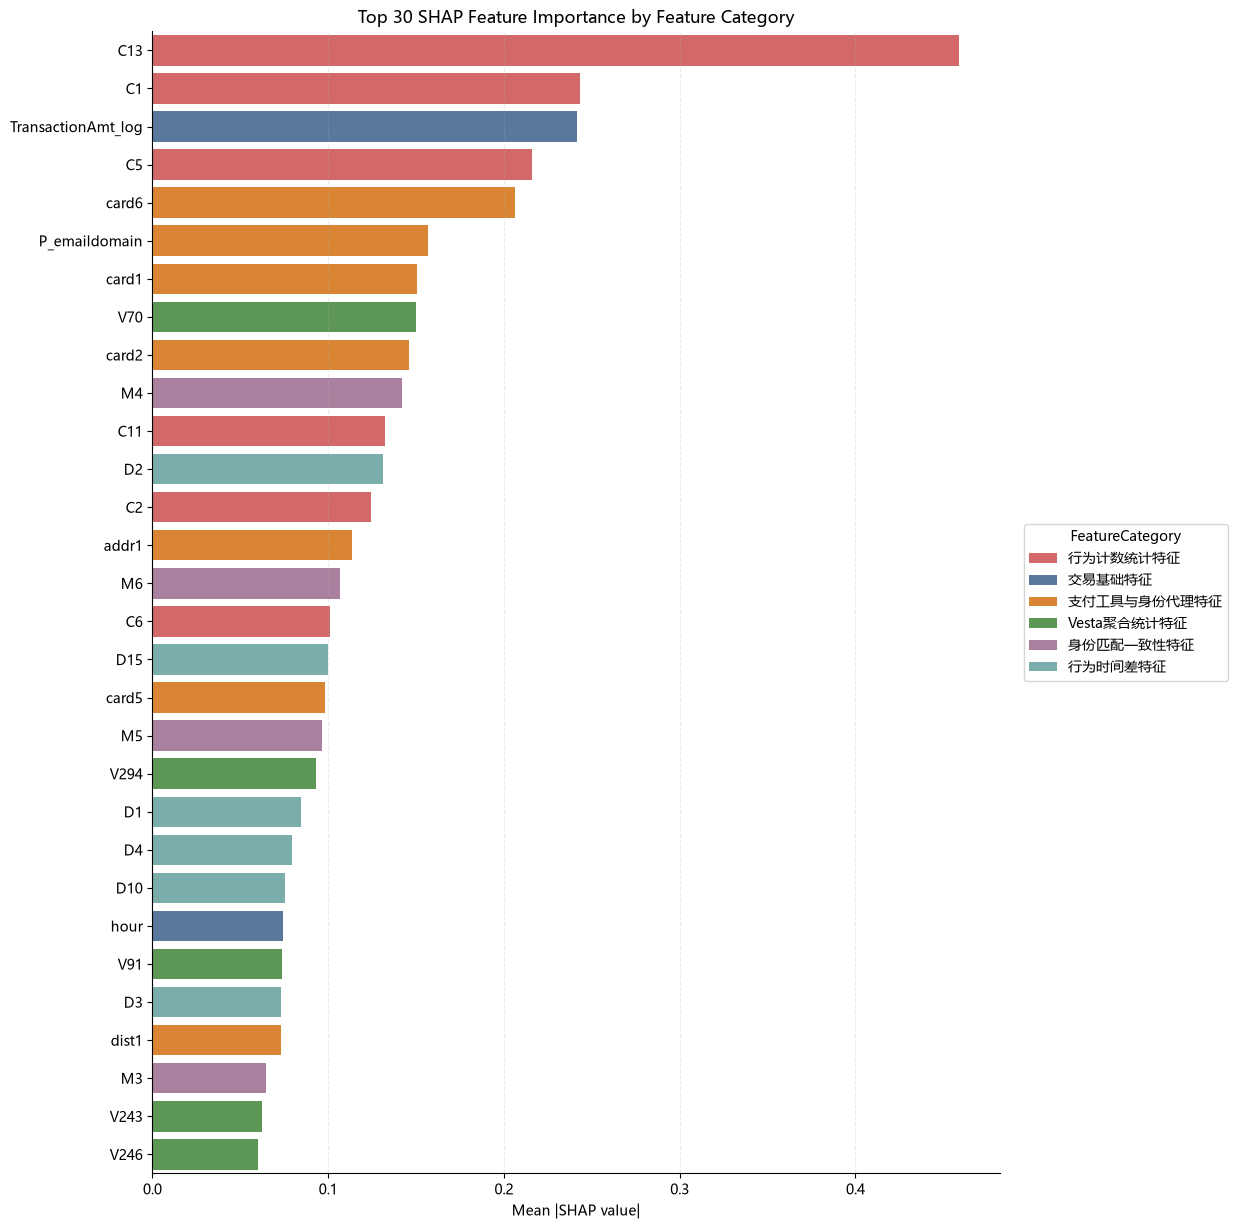

Saved: D:\Vs code\ieee-fraud-project\outputs\iv_002_050\shap\shap_importance_top30_by_category.png


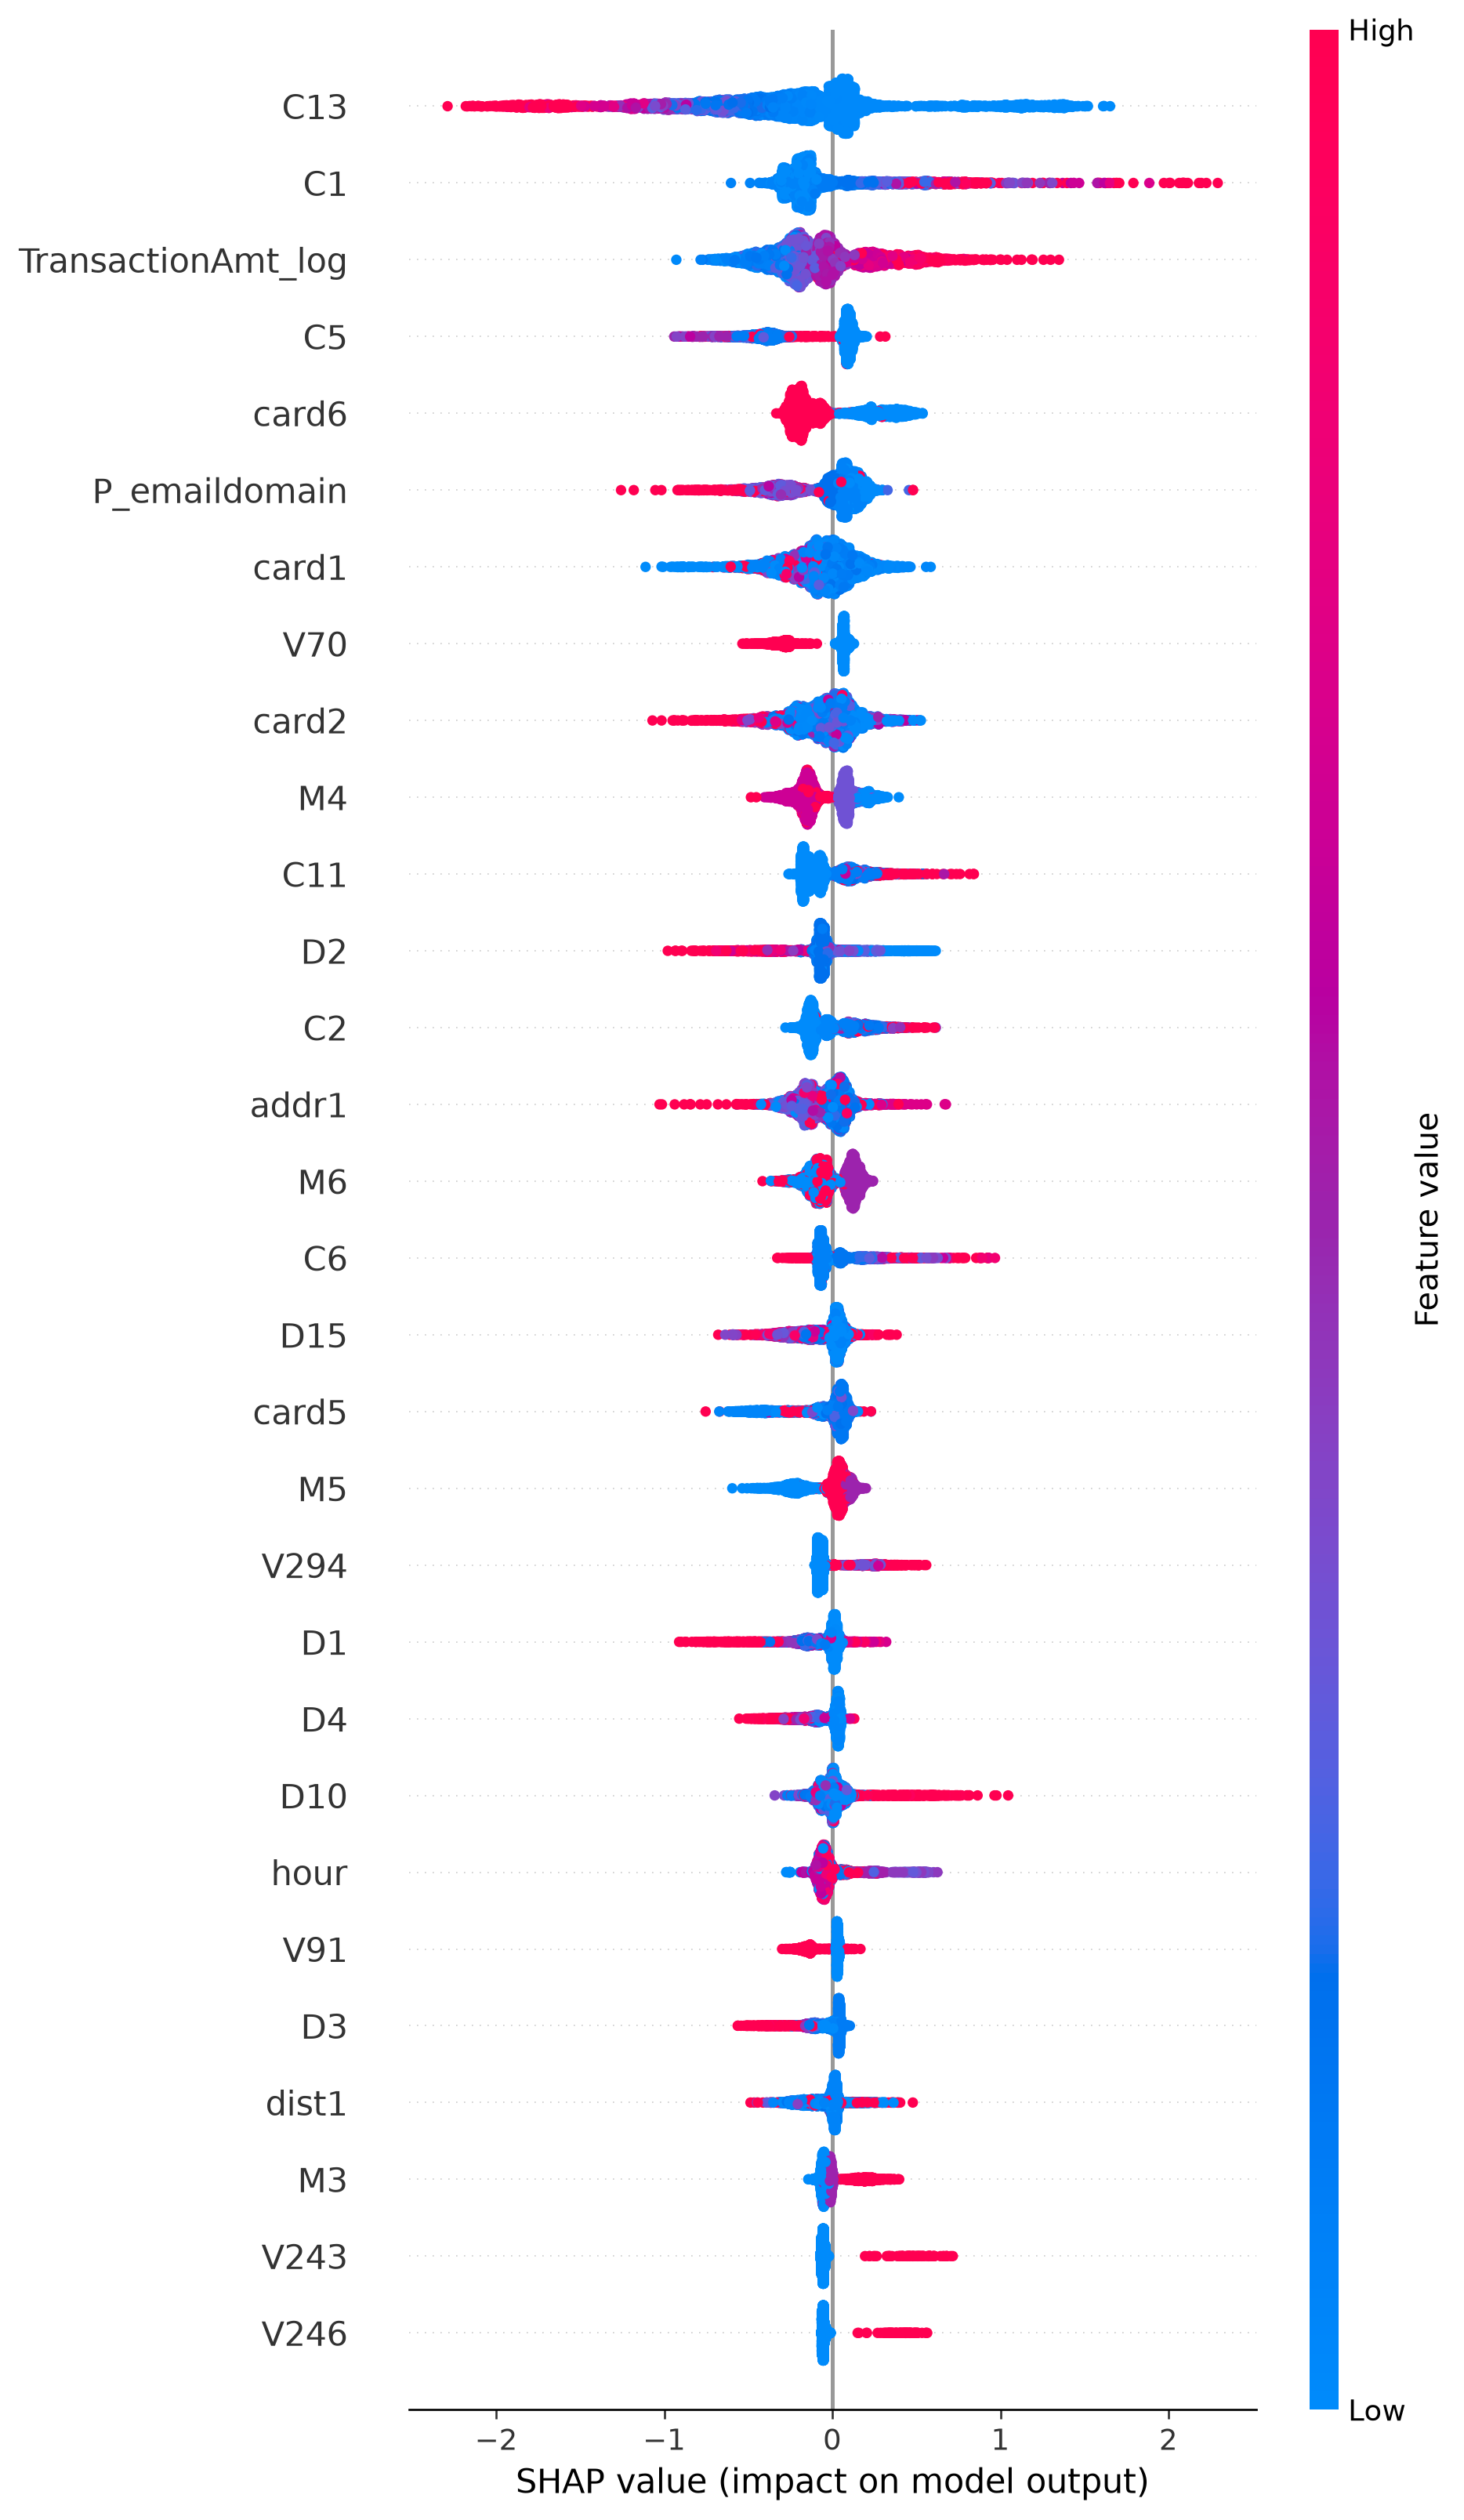

In [7]:
shap_path = outputs / experiment / "shap/shap_importance.csv"
summary_fig_path = outputs / experiment / "shap/shap_summary_top30.png"
colored_fig_path = outputs / experiment / "shap/shap_importance_top30_by_category.png"

category_palette = {
    "交易基础特征": "#4C78A8",
    "支付工具与身份代理特征": "#F58518",
    "行为计数统计特征": "#E45756",
    "行为时间差特征": "#72B7B2",
    "身份匹配一致性特征": "#B279A2",
    "Vesta聚合统计特征": "#54A24B",
    "设备网络与数字指纹特征": "#FF9DA6",
    "未分类": "#9D9D9D",
}

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

if shap_path.exists():
    shap_imp = pd.read_csv(shap_path).head(30).copy()
    shap_imp["FeatureCategory"] = shap_imp["FeatureCategory"].fillna("未分类")
    plot_df = shap_imp

    fig_height = max(7, 0.36 * len(plot_df) + 1.6)
    fig, ax = plt.subplots(figsize=(12.5, fig_height))
    sns.barplot(
        data=plot_df,
        x="MeanAbsSHAP",
        y="Feature",
        hue="FeatureCategory",
        dodge=False,
        palette=category_palette,
        ax=ax,
    )
    ax.set_title("Top 30 SHAP Feature Importance by Feature Category")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.legend(title="FeatureCategory", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig(colored_fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {colored_fig_path}")
else:
    print("No SHAP table found. Run scripts/explain.py first.")

if summary_fig_path.exists():
    display(Image(filename=str(summary_fig_path)))
else:
    print(f"Missing: {summary_fig_path}")
